#Hollywood Movies Data Analysis

This dataset is basically about the movie industry, combining information about:

Movies

Directors

Financial performance

Audience response/popularity

Business Problem:

"What makes a movie successful — and is success about money, quality, or audience reach? And who gets the resources to even try?"

###Data Preperation

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [6]:
df_movies = pd.read_csv('https://drive.google.com/uc?export=download&id=1s2TkjSpzNc4SyxqRrQleZyDIHlc7bxnd')
df_directors =pd.read_csv('https://drive.google.com/uc?export=download&id=1Ws-_s1fHZ9nHfGLVUQurbHDvStePlEJm')
df_movies.head(30)

,Unnamed: 0,id,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day
0,0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday
1,1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday
2,2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday
3,3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday
4,5,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday
5,9,43606,250000000,155,873260194,Batman v Superman: Dawn of Justice,5.7,7004,4771,2016,Mar,Wednesday
6,10,43607,270000000,57,391081192,Superman Returns,5.4,1400,4772,2006,Jun,Wednesday
7,11,43608,200000000,107,586090727,Quantum of Solace,6.1,2965,4773,2008,Oct,Thursday
8,12,43609,200000000,145,1065659812,Pirates of the Caribbean: Dead Man's Chest,7.0,5246,4763,2006,Jun,Tuesday
9,13,43610,255000000,49,89289910,The Lone Ranger,5.9,2311,4763,2013,Jul,Wednesday


In [7]:
df_directors.head(10)

,Unnamed: 0,director_name,id,gender
0,0,James Cameron,4762,Male
1,1,Gore Verbinski,4763,Male
2,2,Sam Mendes,4764,Male
3,3,Christopher Nolan,4765,Male
4,4,Andrew Stanton,4766,Male
5,5,Sam Raimi,4767,Male
6,6,Byron Howard,4768,Male
7,7,Joss Whedon,4769,Male
8,8,David Yates,4770,Male
9,9,Zack Snyder,4771,Male


In [8]:
df_directors.drop(columns=['Unnamed: 0'], inplace=True)
df_movies.drop(columns=['Unnamed: 0'],    inplace=True)


###Dataset Overview

In [9]:
print(df_movies.shape)
print(df_directors.shape)

(1465, 11)
(2349, 3)


In [10]:
df_movies.isnull().sum()
df_directors.isnull().sum()

,0
director_name,0
id,0
gender,625


In [11]:
df_movies.duplicated().sum()
df_directors.duplicated().sum()

np.int64(0)

In [12]:
df_movies.head(5)

,id,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day
0,43597,237000000,150,2787965087,Avatar,7.2,11800,4762,2009,Dec,Thursday
1,43598,300000000,139,961000000,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday
2,43599,245000000,107,880674609,Spectre,6.3,4466,4764,2015,Oct,Monday
3,43600,250000000,112,1084939099,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday
4,43602,258000000,115,890871626,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday


In [13]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1465 non-null   int64  
 1   budget        1465 non-null   int64  
 2   popularity    1465 non-null   int64  
 3   revenue       1465 non-null   int64  
 4   title         1465 non-null   object 
 5   vote_average  1465 non-null   float64
 6   vote_count    1465 non-null   int64  
 7   director_id   1465 non-null   int64  
 8   year          1465 non-null   int64  
 9   month         1465 non-null   object 
 10  day           1465 non-null   object 
dtypes: float64(1), int64(7), object(3)
memory usage: 126.0+ KB


###Data Cleaning

In [14]:
# Gender has 625 nulls — fill with 'Unknown'
df_directors['gender'].fillna('Unknown', inplace=True)

In [15]:
##Zero Value treatment
print("5. ZERO VALUES IN BUDGET / REVENUE")
print("=" * 55)
print(f"  Budget  = 0 : {(df_movies['budget'] == 0).sum()} movies")
print(f"  Revenue = 0 : {(df_movies['revenue'] == 0).sum()} movies")
print("  → Zeros likely mean 'data not available', not actual $0")
print("  → Replacing zeros with NaN so they don't skew aggregations")

df_movies['budget']  = df_movies['budget'].replace(0, np.nan)
df_movies['revenue'] = df_movies['revenue'].replace(0, np.nan)

5. ZERO VALUES IN BUDGET / REVENUE
  Budget  = 0 : 136 movies
  Revenue = 0 : 195 movies
  → Zeros likely mean 'data not available', not actual $0
  → Replacing zeros with NaN so they don't skew aggregations


###Data Merge

In [16]:
df_merged = pd.merge(df_movies, df_directors, left_on='director_id', right_on='id', how='left', suffixes=('_movie', '_director'))
display(df_merged.head())

,id_movie,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day,director_name,id_director,gender
0,43597,237000000.0,150,2.787965e+09,Avatar,7.2,11800,4762,2009,Dec,Thursday,James Cameron,4762,Male
1,43598,300000000.0,139,9.610000e+08,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday,Gore Verbinski,4763,Male
2,43599,245000000.0,107,8.806746e+08,Spectre,6.3,4466,4764,2015,Oct,Monday,Sam Mendes,4764,Male
3,43600,250000000.0,112,1.084939e+09,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday,Christopher Nolan,4765,Male
4,43602,258000000.0,115,8.908716e+08,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday,Sam Raimi,4767,Male


In [17]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_movie       1465 non-null   int64  
 1   budget         1329 non-null   float64
 2   popularity     1465 non-null   int64  
 3   revenue        1270 non-null   float64
 4   title          1465 non-null   object 
 5   vote_average   1465 non-null   float64
 6   vote_count     1465 non-null   int64  
 7   director_id    1465 non-null   int64  
 8   year           1465 non-null   int64  
 9   month          1465 non-null   object 
 10  day            1465 non-null   object 
 11  director_name  1465 non-null   object 
 12  id_director    1465 non-null   int64  
 13  gender         1465 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 160.4+ KB


In [18]:
df_merged.drop(columns=['id_director'], inplace=True)
df_merged.rename(columns={'id_movie': 'movie_id'}, inplace=True)
display(df_merged.head())
df_merged.isnull().sum()

,movie_id,budget,popularity,revenue,title,vote_average,vote_count,director_id,year,month,day,director_name,gender
0,43597,237000000.0,150,2.787965e+09,Avatar,7.2,11800,4762,2009,Dec,Thursday,James Cameron,Male
1,43598,300000000.0,139,9.610000e+08,Pirates of the Caribbean: At World's End,6.9,4500,4763,2007,May,Saturday,Gore Verbinski,Male
2,43599,245000000.0,107,8.806746e+08,Spectre,6.3,4466,4764,2015,Oct,Monday,Sam Mendes,Male
3,43600,250000000.0,112,1.084939e+09,The Dark Knight Rises,7.6,9106,4765,2012,Jul,Monday,Christopher Nolan,Male
4,43602,258000000.0,115,8.908716e+08,Spider-Man 3,5.9,3576,4767,2007,May,Tuesday,Sam Raimi,Male


,0
movie_id,0
budget,136
popularity,0
revenue,195
title,0
vote_average,0
vote_count,0
director_id,0
year,0
month,0


In [19]:
df_merged['budget'] = df_merged['budget'].fillna(df_merged['budget'].median())
df_merged['revenue'] = df_merged['revenue'].fillna(df_merged['revenue'].median())
df_merged.isnull().sum()

,0
movie_id,0
budget,0
popularity,0
revenue,0
title,0
vote_average,0
vote_count,0
director_id,0
year,0
month,0


###On Money — Budget vs. Revenue

####Which movies made the most profit? Which ones were the biggest financial disasters?

In [20]:
df_merged['profit'] = df_merged['revenue'] - df_merged['budget']
df_merged['profit_margin'] = (df_merged['profit'] / df_merged['revenue']) * 100

print("Top 10 Most Profitable Movies:")
display(df_merged[['title', 'profit', 'profit_margin']].sort_values(by='profit', ascending=False).head(10))

print("\nTop 10 Biggest Financial Disasters (Least Profitable Movies):")
display(df_merged[['title', 'profit', 'profit_margin']].sort_values(by='profit', ascending=True).head(10))

Top 10 Most Profitable Movies:


,title,profit,profit_margin
0,Avatar,2.550965e+09,91.499176
19,Titanic,1.645034e+09,89.160092
30,Furious 7,1.316249e+09,87.385887
199,The Lord of the Rings: The Return of the King,1.024889e+09,91.598809
36,Transformers: Dark of the Moon,9.287470e+08,82.647340
21,Skyfall,9.085610e+08,81.958593
26,Transformers: Age of Extinction,8.814051e+08,80.758748
8,Pirates of the Caribbean: Dead Man's Chest,8.656598e+08,81.232285
390,Jurassic Park,8.571000e+08,93.152918
117,Harry Potter and the Philosopher's Stone,8.514756e+08,87.198860



Top 10 Biggest Financial Disasters (Least Profitable Movies):


,title,profit,profit_margin
9,The Lone Ranger,-165710090.0,-185.586580
127,The 13th Warrior,-98301101.0,-159.323914
203,Cutthroat Island,-87982678.0,-878.305379
164,Town & Country,-79627709.0,-767.696442
289,A Sound of Thunder,-74010360.0,-1235.639538
118,R.I.P.D.,-68351500.0,-110.872933
319,Sphere,-61900000.0,-472.519084
352,Osmosis Jones,-61403089.0,-451.595874
286,Timeline,-60519261.0,-310.662039
315,Soldier,-60432117.0,-414.831153


##### Profit Distribution

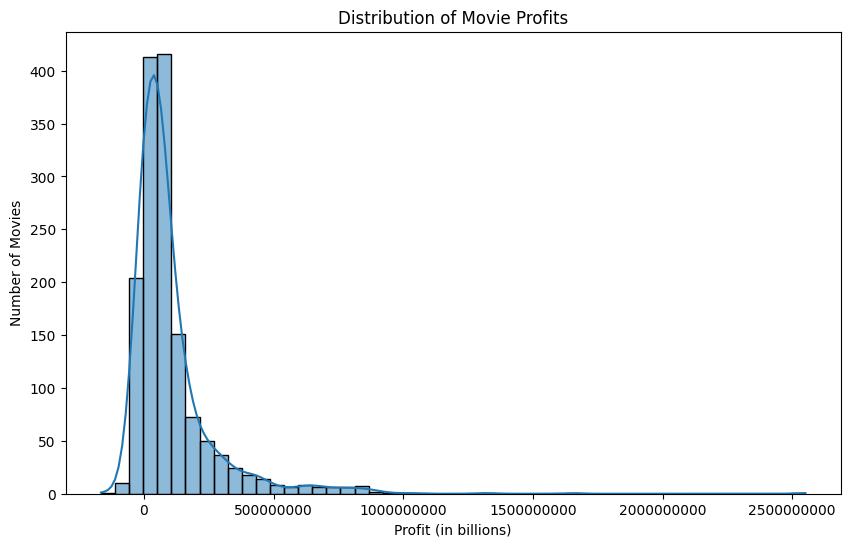

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['profit'], bins=50, kde=True)
plt.title('Distribution of Movie Profits')
plt.xlabel('Profit (in billions)')
plt.ylabel('Number of Movies')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

##### Budget vs. Revenue with Profit Margin

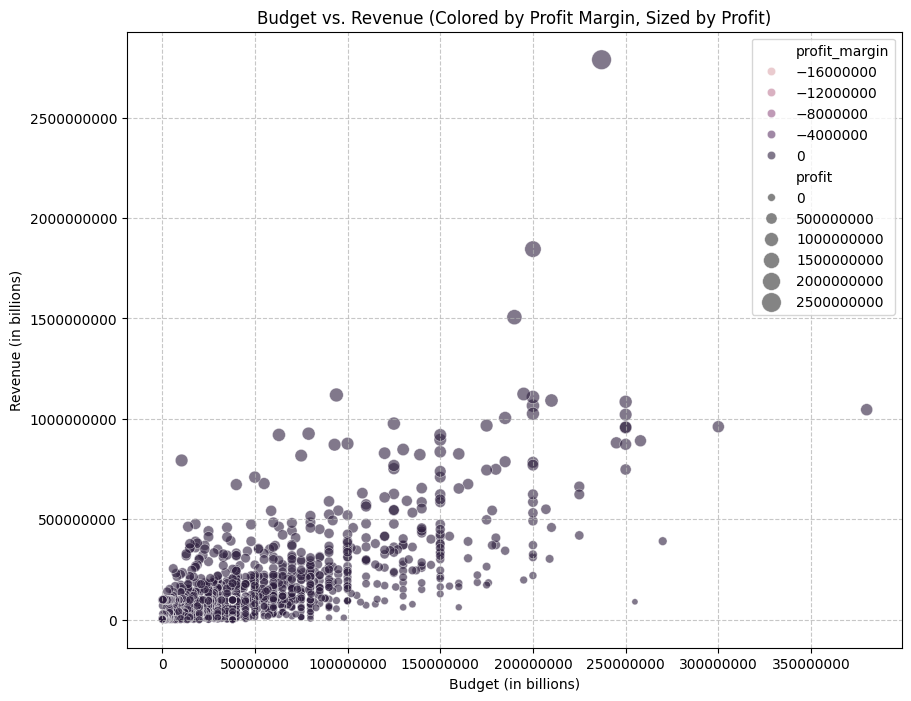

In [22]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_merged, x='budget', y='revenue', hue='profit_margin', size='profit', sizes=(20, 200), alpha=0.6)
plt.title('Budget vs. Revenue (Colored by Profit Margin, Sized by Profit)')
plt.xlabel('Budget (in billions)')
plt.ylabel('Revenue (in billions)')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

####Is there a budget threshold below which financial failure becomes likely?

To determine if there's a budget threshold below which financial failure becomes likely, we can categorize movies based on their `profit` and then analyze the distribution of `budget` for each category. We'll define 'financial failure' as movies with a negative profit.

In [23]:
# Categorize movies based on profit
df_merged['financial_outcome'] = df_merged['profit'].apply(lambda x: 'Loss' if x < 0 else 'Profit')

# Display the count of movies in each category
# print(df_merged['financial_outcome'])
print(df_merged['financial_outcome'].value_counts())

financial_outcome
Profit    1218
Loss       247
Name: count, dtype: int64


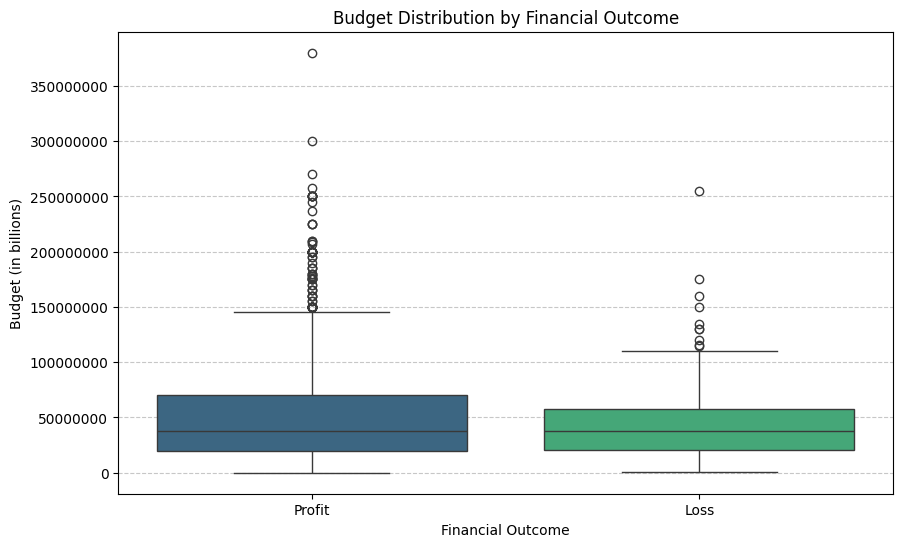

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='financial_outcome', y='budget', data=df_merged, palette='viridis')
plt.title('Budget Distribution by Financial Outcome')
plt.xlabel('Financial Outcome')
plt.ylabel('Budget (in billions)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The box plot above shows the distribution of budgets for movies that resulted in a loss versus those that made a profit. We can observe the median budget and the interquartile range for each group, which might help us identify a potential threshold.

####Do high-budget movies consistently earn more, or is the relationship weak or nonexistent?

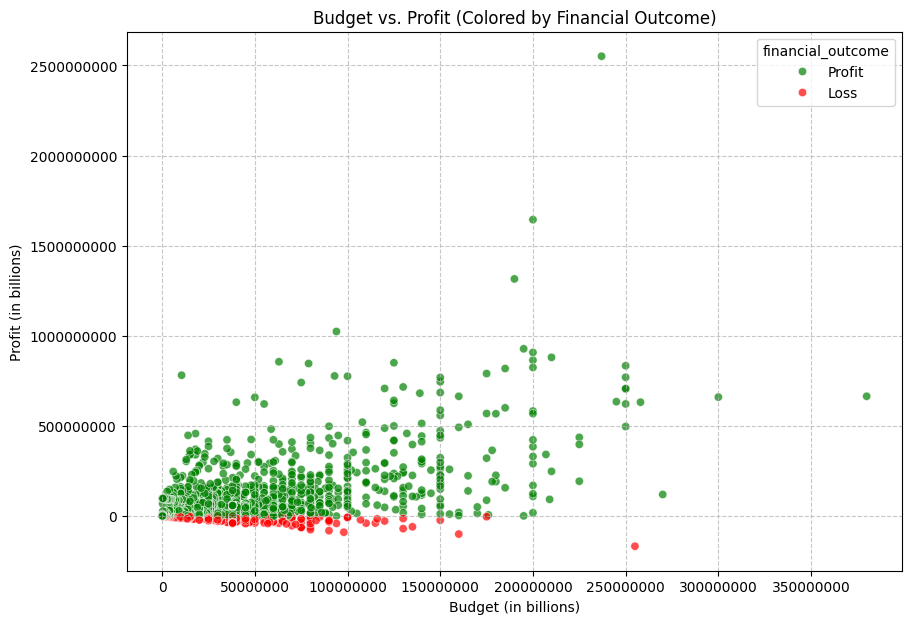

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_merged, x='budget', y='profit', hue='financial_outcome', palette={'Profit': 'green', 'Loss': 'red'}, alpha=0.7)
plt.title('Budget vs. Profit (Colored by Financial Outcome)')
plt.xlabel('Budget (in billions)')
plt.ylabel('Profit (in billions)')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot above visualizes the relationship between a movie's budget and its profit, with points colored based on whether the movie made a profit or incurred a loss. This helps to see if higher budgets generally lead to higher profits and if there's a different pattern for loss-making movies.

Now, let's quantify this relationship using a correlation coefficient.

In [26]:
correlation_budget_profit = df_merged['budget'].corr(df_merged['profit'])
print(f"Correlation between Budget and Profit: {correlation_budget_profit:.2f}")

Correlation between Budget and Profit: 0.53


The correlation coefficient indicates the strength and direction of the linear relationship between budget and profit. A positive value suggests that as budget increases, profit tends to increase, while a value closer to 1 indicates a stronger positive linear relationship. A value closer to 0 suggests a weak or no linear relationship. Based on both the visualization and the correlation, we can assess if high-budget movies consistently earn more.

####What's the return on investment (ROI = revenue / budget) distribution? Are most movies even profitable?

In [27]:
df_merged['ROI'] = df_merged['revenue'] / df_merged['budget']

# Handle potential infinite values if budget was zero (though it should be imputed now)
df_merged['ROI'] = df_merged['ROI'].replace([np.inf, -np.inf], np.nan)

print("ROI has been calculated. Displaying descriptive statistics:")
display(df_merged['ROI'].describe())

ROI has been calculated. Displaying descriptive statistics:


,ROI
count,1465.000000
mean,614.802162
std,23326.216434
min,0.000005
25%,1.439255
50%,2.584489
75%,4.354179
max,892823.318182


Now, let's visualize the distribution of the Return on Investment (ROI) using a histogram to understand its spread and common values.

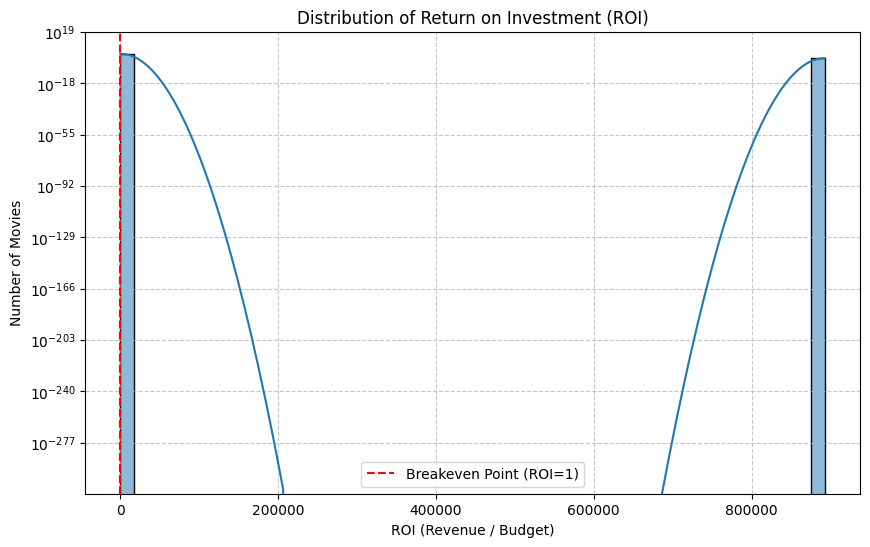

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['ROI'].dropna(), bins=50, kde=True)
plt.title('Distribution of Return on Investment (ROI)')
plt.xlabel('ROI (Revenue / Budget)')
plt.ylabel('Number of Movies')
plt.yscale('log') # Use a log scale for y-axis if there's a long tail
plt.axvline(x=1, color='red', linestyle='--', label='Breakeven Point (ROI=1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The histogram above shows the distribution of ROI, with a vertical dashed line indicating the breakeven point (ROI = 1). Movies to the right of this line are profitable. Let's calculate the percentage of movies that are profitable.

In [29]:
profitable_movies_count = (df_merged['ROI'] > 1).sum()
total_movies_with_roi = df_merged['ROI'].dropna().shape[0]

if total_movies_with_roi > 0:
    percentage_profitable = (profitable_movies_count / total_movies_with_roi) * 100
    print(f"Number of profitable movies (ROI > 1): {profitable_movies_count}")
    print(f"Total movies with calculated ROI: {total_movies_with_roi}")
    print(f"Percentage of profitable movies: {percentage_profitable:.2f}%")
else:
    print("No movies with calculated ROI to determine profitability.")

Number of profitable movies (ROI > 1): 1218
Total movies with calculated ROI: 1465
Percentage of profitable movies: 83.14%


####Are big-budget movies getting more or less risky over time?

In [30]:
# Define 'big-budget' as movies in the top 75th percentile of budget
budget_threshold = df_merged['budget'].quantile(0.75)
print(f"Big-budget threshold (75th percentile): ${budget_threshold:,.2f}")

# Filter for big-budget movies
df_big_budget = df_merged[df_merged['budget'] >= budget_threshold]

# Calculate profitability for big-budget movies (loss if profit <= 0)
df_big_budget['is_loss'] = df_big_budget['profit'] <= 0

# Group by year and calculate the percentage of losses for big-budget movies
risk_over_time = df_big_budget.groupby('year')['is_loss'].mean().reset_index()
risk_over_time['loss_percentage'] = risk_over_time['is_loss'] * 100

display(risk_over_time.head())

Big-budget threshold (75th percentile): $66,000,000.00


,year,is_loss,loss_percentage
0,1989,0.0,0.0
1,1990,0.0,0.0
2,1991,0.0,0.0
3,1992,0.0,0.0
4,1993,0.0,0.0


The table above shows the percentage of big-budget movies that resulted in a loss for each year. Now, let's visualize this trend to see if risk has increased or decreased over time.

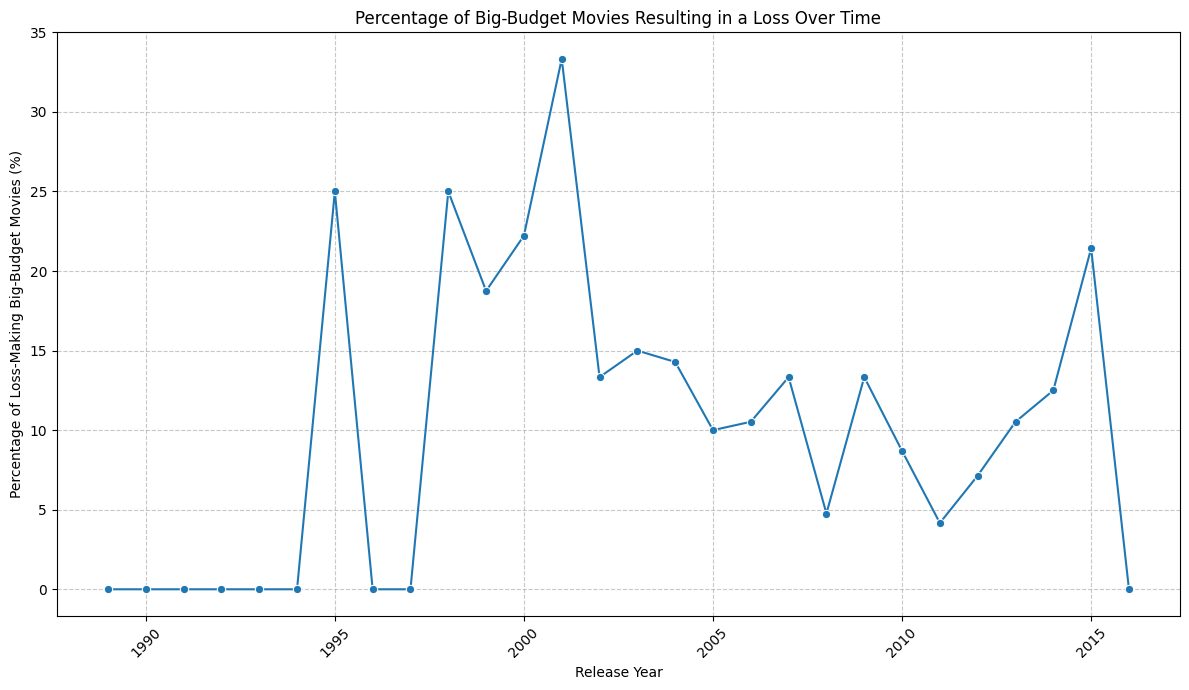

In [31]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=risk_over_time, x='year', y='loss_percentage', marker='o')
plt.title('Percentage of Big-Budget Movies Resulting in a Loss Over Time')
plt.xlabel('Release Year')
plt.ylabel('Percentage of Loss-Making Big-Budget Movies (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The line plot visualizes the trend of risk for big-budget movies over time. An increasing trend would suggest that big-budget movies are becoming riskier, while a decreasing or stable trend would indicate otherwise. We will now interpret this plot to answer your question.

###On Quality — Ratings

####Do the highest-rated movies also make the most money? Or are critical darlings commercial failures?

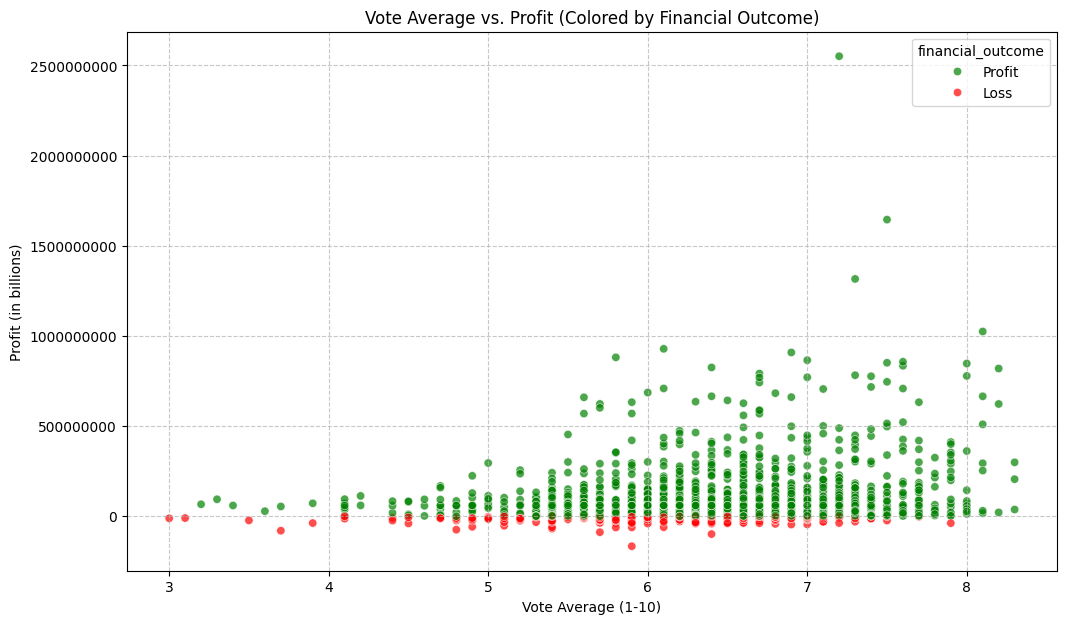

In [32]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='vote_average', y='profit', hue='financial_outcome', palette={'Profit': 'green', 'Loss': 'red'}, alpha=0.7)
plt.title('Vote Average vs. Profit (Colored by Financial Outcome)')
plt.xlabel('Vote Average (1-10)')
plt.ylabel('Profit (in billions)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot above visually represents the relationship between a movie's average rating and its profit, with an indication of whether it was profitable or a loss-maker. This helps to see if high ratings consistently lead to high profits. Now, let's quantify this relationship with a correlation coefficient.

In [33]:
correlation_rating_profit = df_merged['vote_average'].corr(df_merged['profit'])
print(f"Correlation between Vote Average and Profit: {correlation_rating_profit:.2f}")

Correlation between Vote Average and Profit: 0.22


A positive correlation would suggest that higher-rated movies tend to be more profitable, while a value close to zero would imply a weak linear relationship. Let's also examine some of the highest-rated movies to see their actual profit performance and look for any anomalies.

In [34]:
print("Top 10 Highest-Rated Movies by Vote Average (and their Profit):")
display(df_merged[['title', 'vote_average', 'profit', 'financial_outcome']].sort_values(by='vote_average', ascending=False).head(10))

Top 10 Highest-Rated Movies by Vote Average (and their Profit):


,title,vote_average,profit,financial_outcome
1284,Pulp Fiction,8.3,205928762.0,Profit
383,Fight Club,8.3,37853753.0,Profit
901,Schindler's List,8.3,299365567.0,Profit
459,Forrest Gump,8.2,622945399.0,Profit
45,The Dark Knight,8.2,819558444.0,Profit
917,GoodFellas,8.2,21836394.0,Profit
785,Se7en,8.1,294311859.0,Profit
1326,The Usual Suspects,8.1,17341568.0,Profit
58,Interstellar,8.1,510120017.0,Profit
59,Inception,8.1,665532764.0,Profit


And conversely, let's look at some of the movies with high `vote_average` but relatively low `profit` (potential critical darlings that weren't commercial blockbusters).

In [35]:
# To find 'critical darlings, commercial failures', we filter for high vote_average (e.g., > 7.5) and low profit (e.g., in the bottom quartile of profitable movies, or even losses)

high_rated_low_profit = df_merged[(df_merged['vote_average'] >= 7.5) & (df_merged['profit'] <= df_merged['profit'].quantile(0.25))].sort_values(by='profit', ascending=True)

print("Highest-Rated Movies with Lower Profits (Critical Darlings, Commercial Failures?):")
display(high_rated_low_profit[['title', 'vote_average', 'profit', 'financial_outcome']].head(10))

Highest-Rated Movies with Lower Profits (Critical Darlings, Commercial Failures?):


,title,vote_average,profit,financial_outcome
1460,The Last Waltz,7.9,-37678048.0,Loss
701,Gattaca,7.5,-23467223.0,Loss
939,Warrior,7.7,-1942885.0,Loss
1198,True Romance,7.5,-218449.0,Loss
1382,Evil Dead II,7.6,2323044.0,Profit
1420,"Lock, Stock and Two Smoking Barrels",7.5,2547569.0,Profit
1363,Requiem for a Dream,7.9,2890108.0,Profit
1399,Before Sunrise,7.7,3035405.0,Profit
686,The Thing,7.8,4629760.0,Profit
1081,Raging Bull,7.7,5000000.0,Profit


####What's the relationship between vote count and vote average? Can you trust a 9.5-rated movie with 12 votes?

To understand the reliability of `vote_average`, it's crucial to consider the `vote_count`. A movie with a perfect rating based on only a few votes is less trustworthy than a similar rating based on thousands of votes. Let's visualize this relationship.

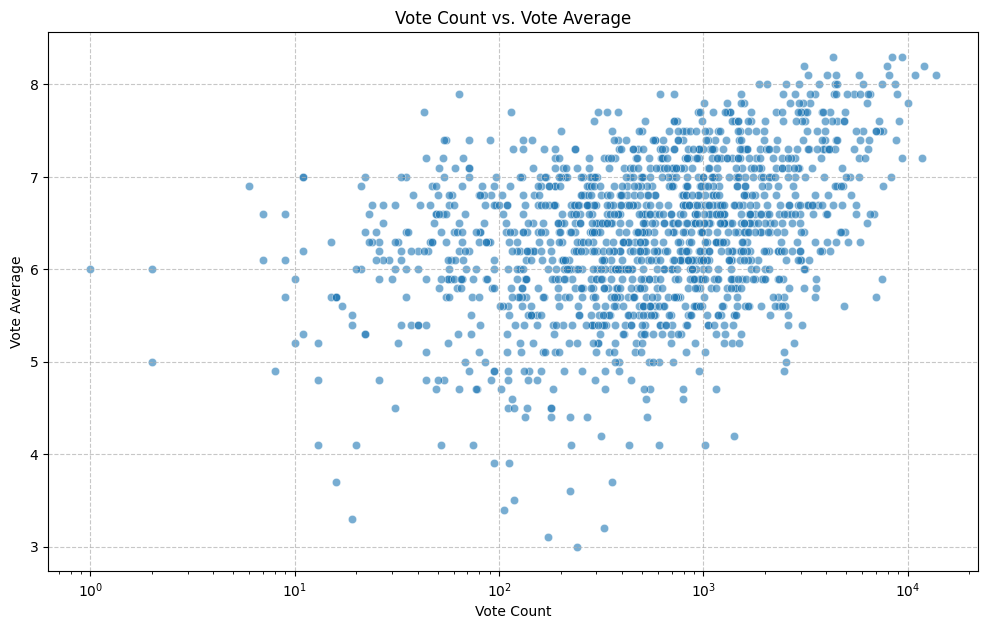

In [36]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='vote_count', y='vote_average', alpha=0.6)
plt.title('Vote Count vs. Vote Average')
plt.xlabel('Vote Count')
plt.ylabel('Vote Average')
plt.xscale('log') # Use a log scale for vote_count due to its wide range
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot above shows the distribution of movies based on their `vote_count` and `vote_average`. Notice how movies with very low vote counts can have extreme `vote_average` values, which might not be representative. As `vote_count` increases, the `vote_average` tends to converge towards the middle values, indicating more reliable ratings.

To address the question about a 9.5-rated movie with 12 votes, let's look at movies with high `vote_average` but low `vote_count`.

In [37]:
# Define a threshold for 'low vote count' (e.g., less than the 10th percentile of vote counts)
vote_count_threshold = df_merged['vote_count'].quantile(0.10)

# Filter for movies with high vote_average (e.g., >= 7.5) and low vote_count
high_rated_low_voted = df_merged[(df_merged['vote_average'] >= 7.5) & (df_merged['vote_count'] <= vote_count_threshold)].sort_values(by='vote_average', ascending=False)

print(f"Movies with Vote Average >= 7.5 and Vote Count <= {int(vote_count_threshold)} (potential unreliable high ratings):")
display(high_rated_low_voted[['title', 'vote_average', 'vote_count']].head(10))

Movies with Vote Average >= 7.5 and Vote Count <= 71 (potential unreliable high ratings):


,title,vote_average,vote_count
1460,The Last Waltz,7.9,64
1434,Kevin Hart: Laugh at My Pain,7.7,43


As seen in the table, there are movies with very high `vote_average` but a very small `vote_count`. This illustrates why you generally **cannot trust a 9.5-rated movie with only 12 votes**.

A small sample size (low `vote_count`) makes the `vote_average` highly susceptible to outliers and not a true reflection of broader audience sentiment. A few enthusiastic or disgruntled voters can heavily sway the average. For a `vote_average` to be considered reliable, it should be backed by a significant number of votes.

####Which directors consistently produce high-rated movies — not just one hit?

To find directors who consistently produce high-rated movies, we need to consider two main factors:

1.  **Average `vote_average`**: The mean rating of all movies directed by an individual.
2.  **Number of movies directed**: To ensure consistency, we should only consider directors who have directed a reasonable number of films (e.g., more than 5 or 10). A director with one highly-rated film doesn't necessarily mean consistent quality.
3.  **Total `vote_count`**: To ensure the average rating is robust and based on a significant audience, especially for directors with fewer movies.

In [38]:
director_ratings = df_merged.groupby('director_name').agg(
    avg_vote_average=('vote_average', 'mean'),
    num_movies=('movie_id', 'count'),
    total_vote_count=('vote_count', 'sum')
).reset_index()
# display(director_ratings)

# Filter for directors with a minimum number of movies (e.g., at least 5 movies)
min_movies_threshold = 5
consistent_directors = director_ratings[director_ratings['num_movies'] >= min_movies_threshold]

# Sort by average vote average in descending order
consistent_directors = consistent_directors.sort_values(by='avg_vote_average', ascending=False)

print(f"Top Directors by Average Vote Average (minimum {min_movies_threshold} movies directed):")
display(consistent_directors.head(10))

Top Directors by Average Vote Average (minimum 5 movies directed):


,director_name,avg_vote_average,num_movies,total_vote_count
30,Christopher Nolan,7.800000,8,62653
145,Quentin Tarantino,7.775000,8,43339
42,David Lynch,7.440000,5,3549
193,Wes Anderson,7.414286,7,10375
39,David Fincher,7.340000,10,36586
142,Peter Jackson,7.333333,9,45533
68,James Cameron,7.328571,7,32819
115,Martin Scorsese,7.300000,19,32521
2,Alejandro González Iñárritu,7.233333,6,13716
135,Paul Thomas Anderson,7.216667,6,5222


The table above shows directors who have consistently produced a certain number of movies and their average `vote_average`. Now, let's visualize the top directors based on their average rating and the number of movies they've directed to provide a better overview.

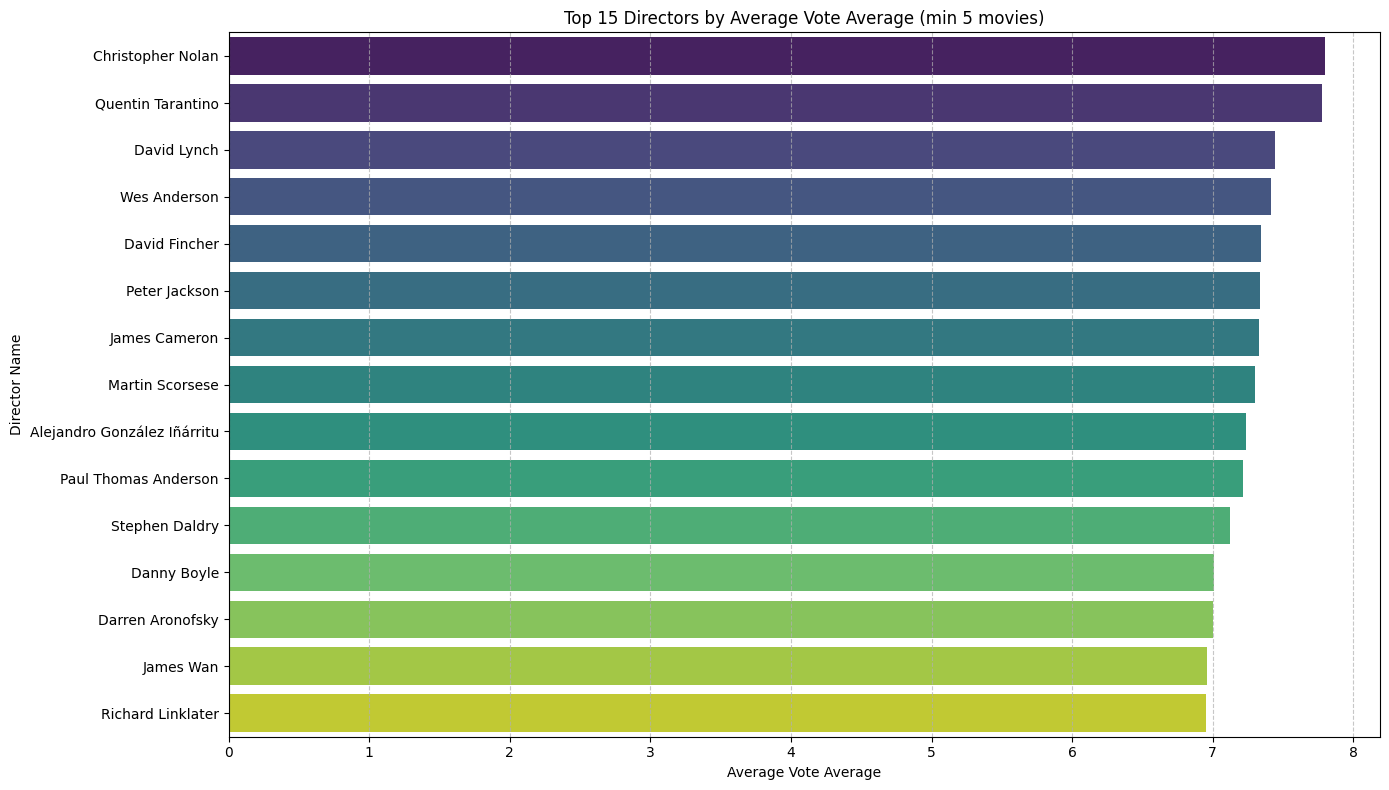

In [39]:
plt.figure(figsize=(14, 8))
sns.barplot(x='avg_vote_average', y='director_name', data=consistent_directors.head(15), palette='viridis')
plt.title(f'Top {15} Directors by Average Vote Average (min {min_movies_threshold} movies)')
plt.xlabel('Average Vote Average')
plt.ylabel('Director Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually represents the top directors with consistently high-rated movies. It helps to quickly identify who, among those with a substantial filmography, maintains a high level of critical acclaim based on audience votes.

###On Popularity

####Popularity vs. vote average — are the most-watched movies the most loved?

To determine if the most-watched movies are the most loved, we will analyze the relationship between `popularity` and `vote_average`. A strong positive correlation would suggest that highly popular movies also tend to be highly rated by audiences.

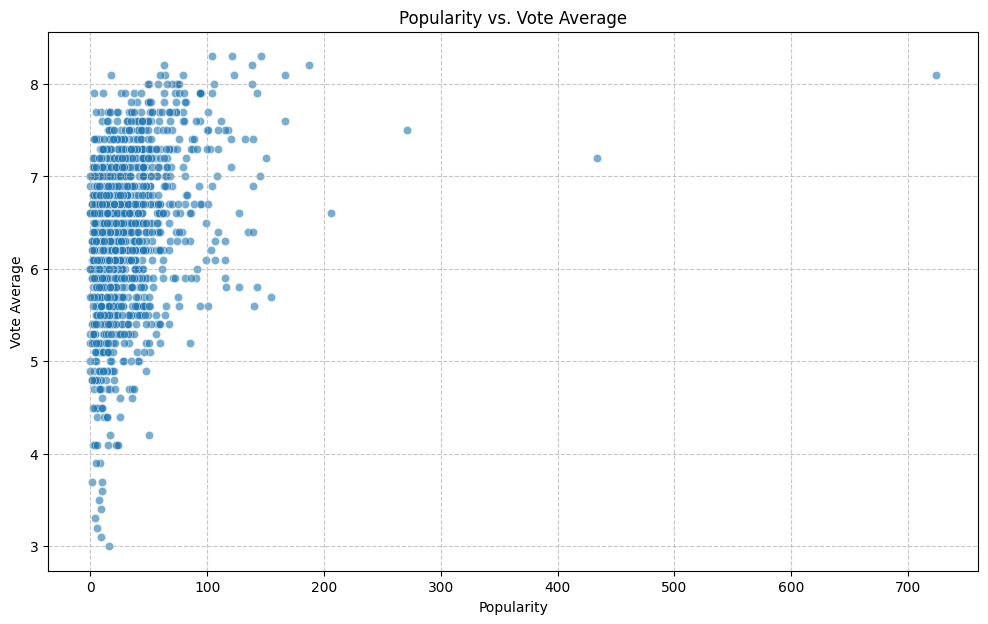

In [40]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='popularity', y='vote_average', alpha=0.6)
plt.title('Popularity vs. Vote Average')
plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot above visualizes the distribution of movies based on their `popularity` and `vote_average`. We can observe if there's a visible trend or cluster of movies that are both highly popular and highly rated. Now, let's quantify this relationship with a correlation coefficient.

In [41]:
correlation_popularity_vote_average = df_merged['popularity'].corr(df_merged['vote_average'])
print(f"Correlation between Popularity and Vote Average: {correlation_popularity_vote_average:.2f}")

Correlation between Popularity and Vote Average: 0.32


A positive correlation indicates that as popularity increases, the vote average tends to increase as well. Let's look at the top movies by popularity and vote average to see if there's an overlap.

In [42]:
print("Top 10 Most Popular Movies (and their Vote Average):")
display(df_merged[['title', 'popularity', 'vote_average']].sort_values(by='popularity', ascending=False).head(10))

print("\nTop 10 Highest-Rated Movies (and their Popularity):")
display(df_merged[['title', 'vote_average', 'popularity']].sort_values(by='vote_average', ascending=False).head(10))

Top 10 Most Popular Movies (and their Vote Average):


,title,popularity,vote_average
58,Interstellar,724,8.1
78,Mad Max: Fury Road,434,7.2
119,Pirates of the Caribbean: The Curse of the Bla...,271,7.5
120,The Hunger Games: Mockingjay - Part 1,206,6.6
45,The Dark Knight,187,8.2
59,Inception,167,8.1
162,The Martian,167,7.6
5,Batman v Superman: Dawn of Justice,155,5.7
0,Avatar,150,7.2
383,Fight Club,146,8.3



Top 10 Highest-Rated Movies (and their Popularity):


,title,vote_average,popularity
1284,Pulp Fiction,8.3,121
383,Fight Club,8.3,146
901,Schindler's List,8.3,104
459,Forrest Gump,8.2,138
45,The Dark Knight,8.2,187
917,GoodFellas,8.2,63
785,Se7en,8.1,79
1326,The Usual Suspects,8.1,64
58,Interstellar,8.1,724
59,Inception,8.1,167


By comparing the lists of the most popular movies and the highest-rated movies, along with the correlation coefficient, we can draw conclusions about whether popularity and critical reception (as reflected by vote average) generally align or diverge.

####How does popularity correlate with revenue? Is popularity a leading indicator of box office success?

In [43]:
correlation_popularity_revenue = df_merged['popularity'].corr(df_merged['revenue'])
print(f"Correlation between Popularity and Revenue: {correlation_popularity_revenue:.2f}")

Correlation between Popularity and Revenue: 0.57


A positive correlation between popularity and revenue would suggest that more popular movies tend to generate higher revenues. Now, let's visualize this relationship with a scatter plot.

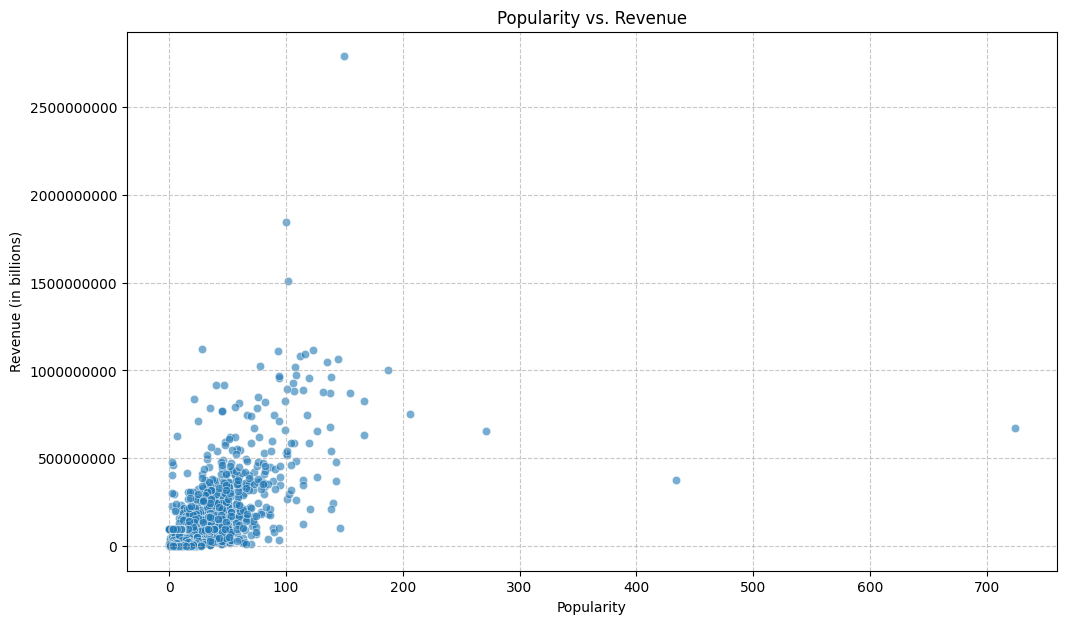

In [44]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='popularity', y='revenue', alpha=0.6)
plt.title('Popularity vs. Revenue')
plt.xlabel('Popularity')
plt.ylabel('Revenue (in billions)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot above visually represents the relationship between a movie's popularity and its revenue. We can observe if there's a visible trend or clustering indicating that higher popularity often correlates with higher revenue. To further investigate if popularity is a *leading indicator* of box office success, let's compare the top movies by popularity and top movies by revenue.

In [45]:
print("\nTop 10 Most Popular Movies (and their Revenue):")
display(df_merged[['title', 'popularity', 'revenue']].sort_values(by='popularity', ascending=False).head(10))

print("\nTop 10 Highest Revenue Movies (and their Popularity):")
display(df_merged[['title', 'revenue', 'popularity']].sort_values(by='revenue', ascending=False).head(10))


Top 10 Most Popular Movies (and their Revenue):


,title,popularity,revenue
58,Interstellar,724,6.751200e+08
78,Mad Max: Fury Road,434,3.788583e+08
119,Pirates of the Caribbean: The Curse of the Bla...,271,6.550112e+08
120,The Hunger Games: Mockingjay - Part 1,206,7.521002e+08
45,The Dark Knight,187,1.004558e+09
59,Inception,167,8.255328e+08
162,The Martian,167,6.301619e+08
5,Batman v Superman: Dawn of Justice,155,8.732602e+08
0,Avatar,150,2.787965e+09
383,Fight Club,146,1.008538e+08



Top 10 Highest Revenue Movies (and their Popularity):


,title,revenue,popularity
0,Avatar,2.787965e+09,150
19,Titanic,1.845034e+09,100
30,Furious 7,1.506249e+09,102
36,Transformers: Dark of the Moon,1.123747e+09,28
199,The Lord of the Rings: The Return of the King,1.118889e+09,123
21,Skyfall,1.108561e+09,93
26,Transformers: Age of Extinction,1.091405e+09,116
3,The Dark Knight Rises,1.084939e+09,112
8,Pirates of the Caribbean: Dead Man's Chest,1.065660e+09,145
12,Pirates of the Caribbean: On Stranger Tides,1.045714e+09,135


By comparing these lists and considering the correlation coefficient and the scatter plot, we can assess how strongly popularity aligns with box office success. If there's a significant overlap between the top popular movies and the top revenue-generating movies, and a strong positive correlation, it suggests that popularity can indeed be a strong indicator of box office success.

###On Directors

####Who are the most prolific directors — and does output volume relate to quality?

In [48]:
director_productivity = df_merged.groupby('director_name').agg(
    num_movies=('movie_id', 'count'),
    avg_vote_average=('vote_average', 'mean'),
    total_revenue=('revenue', 'sum')
).reset_index()

# Sort by number of movies to find the most prolific directors
most_prolific_directors = director_productivity.sort_values(by='num_movies', ascending=False)

print("Top 10 Most Prolific Directors by Number of Movies:")
display(most_prolific_directors.head(10))

Top 10 Most Prolific Directors by Number of Movies:


,director_name,num_movies,avg_vote_average,total_revenue
179,Steven Spielberg,26,6.953846,8.676739e+09
115,Martin Scorsese,19,7.300000,2.248268e+09
32,Clint Eastwood,19,6.836842,2.496359e+09
196,Woody Allen,18,6.672222,1.504801e+09
158,Robert Rodriguez,16,5.875000,1.109900e+09
172,Spike Lee,16,6.456250,1.028093e+09
151,Ridley Scott,16,6.693750,3.189558e+09
147,Renny Harlin,15,5.720000,1.031501e+09
178,Steven Soderbergh,15,6.326667,2.213075e+09
132,Oliver Stone,14,6.614286,1.376259e+09


The table above shows the directors who have made the most movies. Now, let's visualize the relationship between the number of movies directed and their average `vote_average` to see if higher output volume correlates with higher quality.

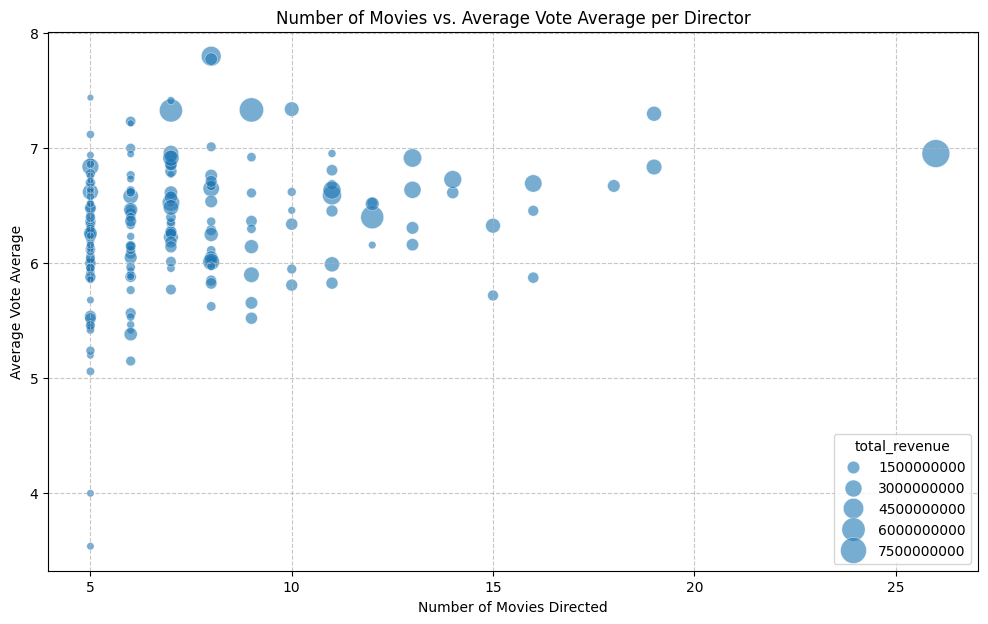

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(data=director_productivity, x='num_movies', y='avg_vote_average', size='total_revenue', sizes=(20, 400), alpha=0.6)
plt.title('Number of Movies vs. Average Vote Average per Director')
plt.xlabel('Number of Movies Directed')
plt.ylabel('Average Vote Average')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot visualizes the relationship between a director's filmography size (number of movies) and the average quality of their films (average `vote_average`). The size of the points is scaled by the total revenue generated by the director's movies.

From this visualization and the previously generated table, we can assess if there's a trend: do directors who make more movies tend to have higher or lower average ratings? Or is there no clear relationship between quantity and quality?

####Is there a director whose average rating improves with every film, showing growth? Or one whose quality declines?

In [52]:
def plot_director_rating_trend(director_name, df):
    director_films = df[df['director_name'] == director_name].sort_values(by='year')

    if len(director_films) < 2:
        print(f"Not enough films ({len(director_films)}) for {director_name} to show a trend.")
        return

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=director_films.index, y='vote_average', data=director_films, marker='o', label='Individual Film Rating')
    # Calculate a rolling average for smoother trend visualization
    director_films['rolling_avg_rating'] = director_films['vote_average'].rolling(window=2, min_periods=1).mean()
    sns.lineplot(x=director_films.index, y='rolling_avg_rating', data=director_films, color='red', linestyle='--', label='Rolling Average Rating')

    # Add a simple linear trend line
    x_values = np.arange(len(director_films))
    y_values = director_films['vote_average'].values
    if len(x_values) > 1:
        slope, intercept = np.polyfit(x_values, y_values, 1)
        plt.plot(director_films.index, intercept + slope * x_values, color='green', linestyle=':', label=f'Linear Trend (Slope: {slope:.2f})')

    plt.title(f'Film Rating Trend for {director_name}')
    plt.xlabel('Film Index (Chronological Order)')
    plt.ylabel('Vote Average')
    plt.ylim(3, 9) # Set consistent y-axis limits for comparison
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

Let's apply this function to a few well-known directors to observe their career trends. We'll pick directors with a substantial number of films to make the trend analysis more meaningful.

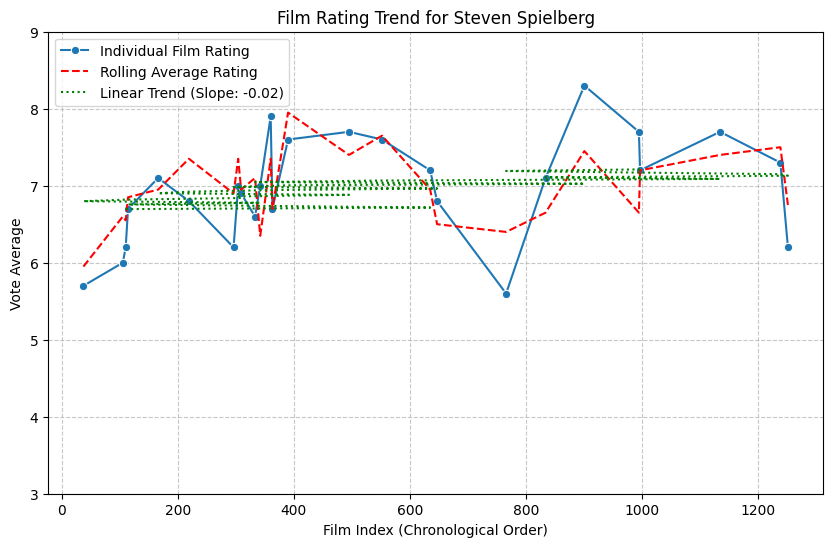

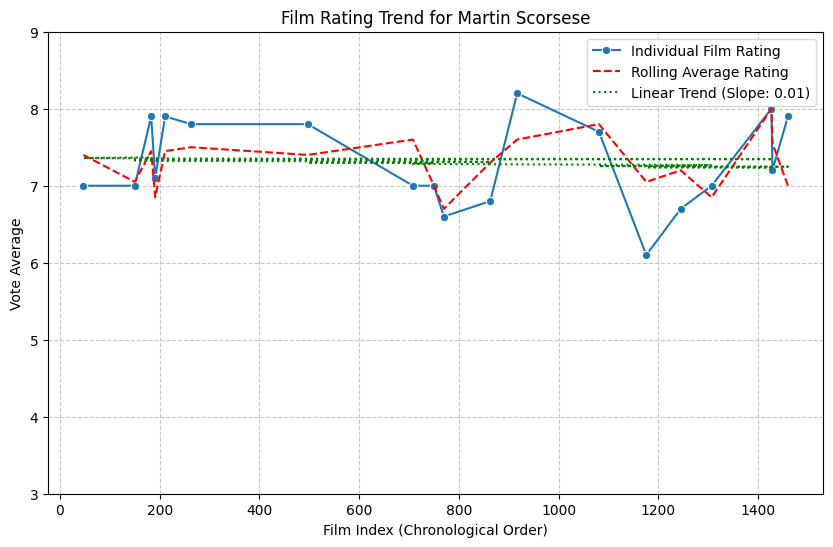

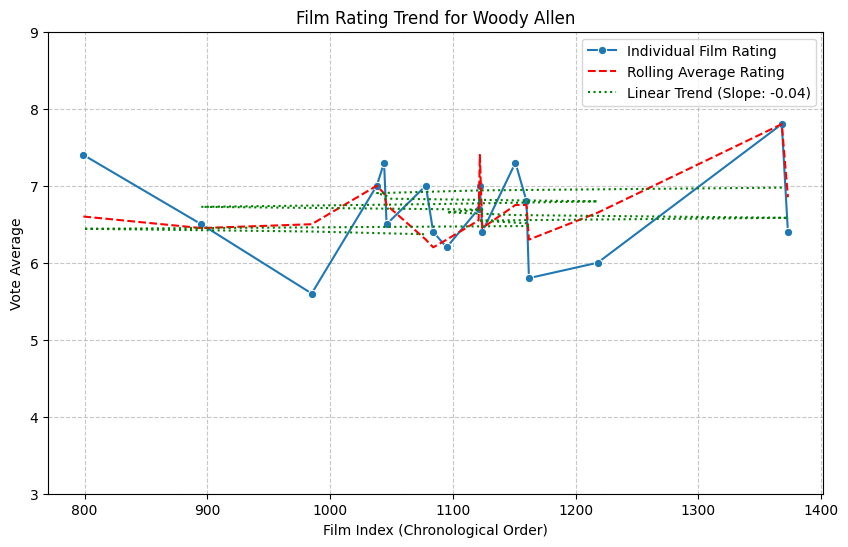

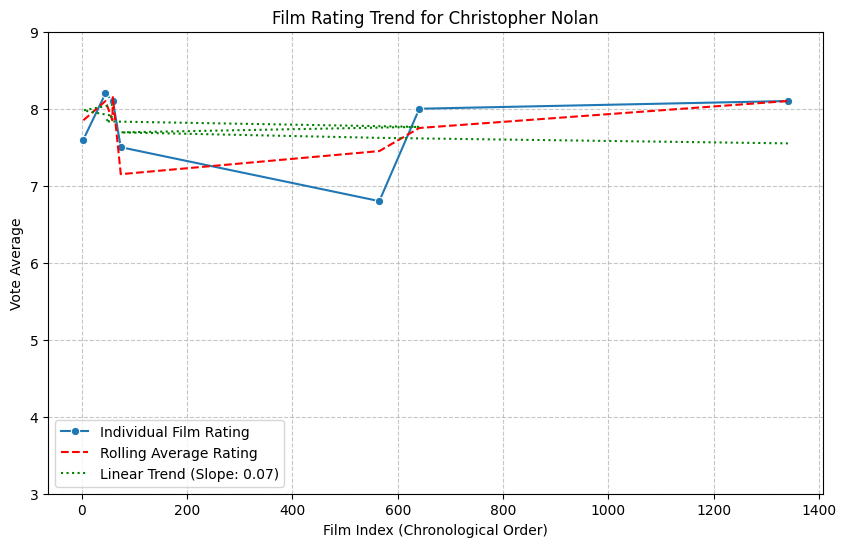

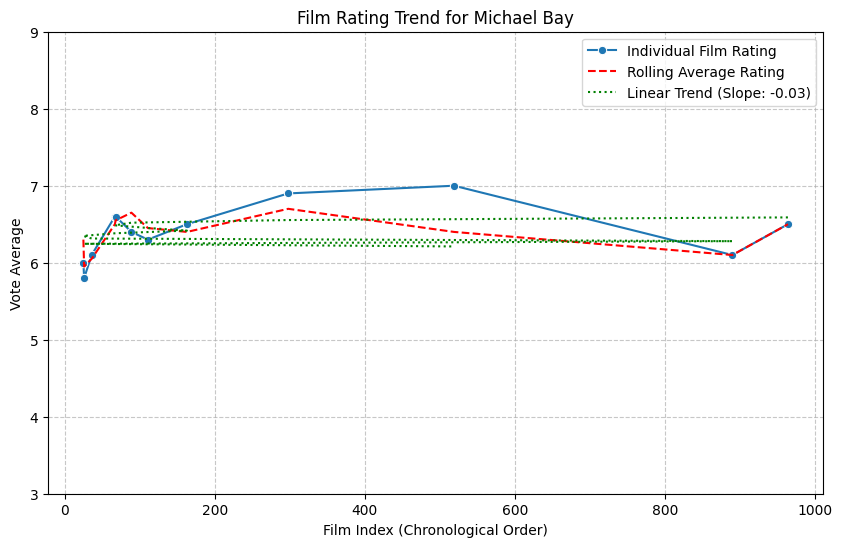

In [50]:
# Select a few directors from the 'most_prolific_directors' list with a good number of films
sample_directors = ['Steven Spielberg', 'Martin Scorsese', 'Woody Allen', 'Christopher Nolan', 'Michael Bay']

for director in sample_directors:
    plot_director_rating_trend(director, df_merged)

The plots above illustrate the `vote_average` trend for selected directors over their careers. The individual film ratings (blue dots), a rolling average (red dashed line), and a linear trend line (green dotted line) help visualize patterns of growth or decline.

*   **Directors showing growth:** If the green linear trend line has a positive slope, it suggests an improving trend in average ratings over time. For example, if a director's late-career films consistently score higher than their early ones.
*   **Directors showing decline:** A negative slope on the linear trend line would indicate a general decline in average ratings through their filmography.
*   **Directors with stable quality:** A relatively flat linear trend line would suggest consistent quality, with fluctuations but no clear upward or downward trajectory.

By examining the slopes of the trend lines and the overall pattern, we can identify individual directors whose average ratings have evolved significantly over their careers.

####Which director has the highest average ROI — not just the highest-grossing, but the most efficient filmmaker financially?

In [53]:
director_roi = df_merged.groupby('director_name')['ROI'].mean().reset_index()

# Sort by average ROI in descending order
top_roi_directors = director_roi.sort_values(by='ROI', ascending=False)

print("Top 10 Directors by Average ROI:")
display(top_roi_directors.head(10))

Top 10 Directors by Average ROI:


,director_name,ROI
198,Zhang Yimou,148806.277883
42,David Lynch,143.427505
84,John Landis,44.957010
61,George Miller,39.076975
71,James Wan,30.307155
112,Marc Forster,27.930681
82,John Carpenter,27.470211
100,Kevin Smith,16.694616
35,Darren Aronofsky,15.222139
36,Darren Lynn Bousman,14.228731


The table above highlights directors based on their average Return on Investment (ROI). A high average ROI indicates that these directors consistently produce films that generate significant revenue relative to their budget, making them the most financially efficient filmmakers. It's important to note that some directors might appear high on this list due to a few extremely successful low-budget films, while others might have a more consistent track record across a larger filmography. This metric focuses purely on financial efficiency rather than gross revenue.

###On Outliers — The Most Interesting Data Points

####Which movie had the highest budget but lowest revenue — what went wrong?

In [54]:
# Sort by profit in ascending order to find the movie with the largest loss
biggest_financial_disaster = df_merged.sort_values(by='profit', ascending=True).head(1)

print("Movie with the Highest Budget and Lowest Revenue (Largest Financial Loss):")
display(biggest_financial_disaster[['title', 'budget', 'revenue', 'profit', 'profit_margin', 'director_name', 'year']])

Movie with the Highest Budget and Lowest Revenue (Largest Financial Loss):


,title,budget,revenue,profit,profit_margin,director_name,year
9,The Lone Ranger,255000000.0,89289910.0,-165710090.0,-185.58658,Gore Verbinski,2013


The table above shows the movie that had the largest financial loss. To understand 'what went wrong', we can infer several factors:

*   **High Budget, Low Revenue:** The primary issue is a large discrepancy between the `budget` and the `revenue`, resulting in a significant negative `profit`. This indicates the film failed to attract a sufficient audience to cover its production and marketing costs.

*   **Critical Reception (Vote Average):** While not explicitly shown in this table, a low `vote_average` would suggest poor critical reception, which can deter audiences. Conversely, even a decent `vote_average` might not save a movie if marketing was poor or if it faced strong competition.

*   **Popularity:** A low `popularity` score would directly correlate with low audience interest, contributing to the low revenue.

*   **Timing/Competition:** The `year` of release might play a role. Was it released during a highly competitive period? Did it go up against major blockbusters?

*   **Director's Track Record:** The `director_name` could also offer context. Is this an outlier for an otherwise successful director, or part of a pattern?

Without external information, we can only speculate, but the raw numbers clearly point to a project where investment far outstripped audience engagement and financial return.

####Which movie had near-zero budget but massive revenue — what went right?

In [55]:
budget_low_threshold = df_merged['budget'].quantile(0.10)

# Filter for movies with a budget below the threshold and a high ROI (e.g., top 10% of ROI)
high_roi_low_budget_movies = df_merged[
    (df_merged['budget'] <= budget_low_threshold) &
    (df_merged['ROI'] >= df_merged['ROI'].quantile(0.90)) # Using 90th percentile for 'massive revenue' via ROI
].sort_values(by='ROI', ascending=False)

print(f"Movies with a budget <= ${budget_low_threshold:,.2f} (10th percentile) and high ROI:")
display(high_roi_low_budget_movies[['title', 'budget', 'revenue', 'profit', 'ROI', 'director_name', 'year', 'vote_average', 'vote_count']].head(10))

Movies with a budget <= $9,000,000.00 (10th percentile) and high ROI:


,title,budget,revenue,profit,ROI,director_name,year,vote_average,vote_count
590,Curse of the Golden Flower,110.0,98210565.0,98210455.0,892823.318182,Zhang Yimou,2006,6.6,203
1456,Eraserhead,10000.0,7000000.0,6990000.0,700.000000,David Lynch,1977,7.5,485
1450,Mad Max,400000.0,100000000.0,99600000.0,250.000000,George Miller,1979,6.6,1213
1102,Halloween,300000.0,70000000.0,69700000.0,233.333333,John Carpenter,1978,7.4,1035
1438,Everything Put Together,500000.0,98210565.0,97710565.0,196.421130,Marc Forster,2001,5.0,2
1435,The Kentucky Fried Movie,600000.0,98210565.0,97610565.0,163.684275,John Landis,1977,6.4,66
1461,Clerks,27000.0,3151130.0,3124130.0,116.708519,Kevin Smith,1994,7.4,755
1424,Saw,1200000.0,103911669.0,102711669.0,86.593058,James Wan,2004,7.2,2184
1443,The Evil Dead,350000.0,29400000.0,29050000.0,84.000000,Sam Raimi,1981,7.3,894
1423,"Sex, Lies, and Videotape",1200000.0,98210565.0,97010565.0,81.842138,Steven Soderbergh,1989,6.7,185


The table above shows movies that achieved massive revenue despite a near-zero budget, indicated by their exceptionally high Return on Investment (ROI). To understand 'what went right' for these films:

*   **Exceptional ROI:** These movies have an outstanding ratio of revenue to budget, meaning they were incredibly cost-effective.

*   **Audience Resonance:** Often, such films tap into a niche audience, a compelling story, or a unique style that resonates widely without needing a massive marketing push. Word-of-mouth can play a significant role.

*   **Critical Acclaim/Popularity (Post-Release):** While they might not have had high pre-release hype, some gain critical acclaim or become popular after release, driving audiences to theaters or streaming platforms.

*   **Effective Marketing:** Even with a low budget, clever and targeted marketing (often digital or viral) can make a huge difference.

*   **Strong Story/Concept:** A brilliant script, innovative concept, or a breakout performance can overcome budgetary limitations.

*   **Talent Efficiency:** Directors and crew might have worked on a passion project basis, or the production process was extremely efficient.

These films often become case studies in successful independent filmmaking, demonstrating that financial success isn't solely dependent on the size of the initial investment.

####Which movies have thousands of votes but a low average — universally disliked blockbusters?

In [56]:
vote_count_high_threshold = df_merged['vote_count'].quantile(0.90)
vote_average_low_threshold = df_merged['vote_average'].quantile(0.25)

# Filter for movies with high vote count and low vote average
universally_disliked_blockbusters = df_merged[
    (df_merged['vote_count'] >= vote_count_high_threshold) &
    (df_merged['vote_average'] <= vote_average_low_threshold)
].sort_values(by='vote_average', ascending=True)

print(f"Movies with Vote Count >= {int(vote_count_high_threshold)} (90th percentile) and Vote Average <= {vote_average_low_threshold:.2f} (25th percentile - Universally Disliked Blockbusters):")
display(universally_disliked_blockbusters[['title', 'vote_count', 'vote_average', 'budget', 'revenue', 'profit', 'financial_outcome']].head(10))

Movies with Vote Count >= 2951 (90th percentile) and Vote Average <= 5.90 (25th percentile - Universally Disliked Blockbusters):


,title,vote_count,vote_average,budget,revenue,profit,financial_outcome
100,G.I. Joe: Retaliation,3025,5.4,130000000.0,3.718763e+08,241876278.0,Profit
40,2012,4903,5.6,200000000.0,7.696536e+08,569653595.0,Profit
5,Batman v Superman: Dawn of Justice,7004,5.7,250000000.0,8.732602e+08,623260194.0,Profit
27,Oz: The Great and Powerful,3530,5.7,200000000.0,4.918685e+08,291868548.0,Profit
695,Twilight,3561,5.8,37000000.0,3.926166e+08,355616625.0,Profit
26,Transformers: Age of Extinction,3095,5.8,210000000.0,1.091405e+09,881405097.0,Profit
4,Spider-Man 3,3576,5.9,258000000.0,8.908716e+08,632871626.0,Profit
50,Suicide Squad,7458,5.9,175000000.0,7.450000e+08,570000000.0,Profit


The table above lists movies that have received a large number of votes (indicating high visibility or popularity) but have a low average rating, which aligns with the definition of "universally disliked blockbusters."

To understand "what went wrong" for these films, we can consider several factors:

*   **High Expectations vs. Reality:** Often, these movies might have had large budgets, extensive marketing, and popular stars, leading to high audience expectations. When the film fails to meet these expectations, the large audience base translates into a high volume of negative reviews.
*   **Quality Issues:** Despite potentially high production values, the core story, acting, direction, or overall execution might be perceived as poor by a significant portion of the audience.
*   **Franchise Fatigue/Missteps:** For movies belonging to established franchises, a deviation from beloved elements or a perceived misinterpretation of source material can lead to widespread disapproval from fans.
*   **Audience Polarization:** Some films might be highly divisive, loved by a small segment but disliked by a much larger one, leading to a low average rating despite a high vote count.
*   **Marketing vs. Content Disconnect:** If the marketing heavily misrepresents the film's actual content or tone, it can lead to audience disappointment and negative reactions.